In [1]:
import sys
from google.colab import drive

drive.mount('/content/drive')

PACKAGE_DIR = '/content/drive/MyDrive/AUS LAB II/drone_detection'
PARENT_DIR = '/content/drive/MyDrive/AUS LAB II'

# Remove the package directory itself if it was added earlier
sys.path = [p for p in sys.path if p != PACKAGE_DIR]

# Ensure only the parent is on sys.path
if PARENT_DIR not in sys.path:
  sys.path.insert(0, PARENT_DIR)

# Clear stale top-level and package modules
to_delete = []
for name in list(sys.modules):
  if name in {
    'config', 'audio_processing', 'models', 'datasets', 'training',
    'inference', 'tracking', 'multidrone', 'visualization',
    'batch_testing', 'orchestration'
  }:
    to_delete.append(name)
  elif name == 'drone_detection' or name.startswith('drone_detection.'):
    to_delete.append(name)

for name in to_delete:
  del sys.modules[name]

print("Removed stale modules:", sorted(to_delete))
print("sys.path[0:5] =", sys.path[:5])

Mounted at /content/drive
Removed stale modules: []
sys.path[0:5] = ['/content/drive/MyDrive/AUS LAB II', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12']


In [ ]:
from pathlib import Path
import re

root = Path('/content/drive/MyDrive/AUS LAB II/drone_detection')

for pyfile in sorted(root.glob('*.py')):
  print(f"\n--- {pyfile.name} ---")
  text = pyfile.read_text(errors='ignore')
  for line in text.splitlines():
    s = line.strip()
    if s.startswith('import ') or s.startswith('from '):
      print(s)

In [2]:
# Import the project API

from drone_detection.config import config
from drone_detection.orchestration import (
  quickstart_notebook_setup_v2,
  configure_custom_dataset,
  describe_custom_dataset,
  validate_custom_dataset_structure,
  upload_custom_dataset_artifacts,
  import_custom_builder_dataset,
  collect_background_pool,
  generate_mixed_drone_training_audio,
  report_detection_split_counts,
  audit_localization_labels,
  diagnose_uavirbase,
  verify_tdoa_accuracy,
  train_detection,
  train_localization,
  train_all,
  quick_demo,
  launch_ui,
)
from drone_detection.inference import comprehensive_pipeline_test
# Synthetic dataset generator
from drone_detection.synthetic_dataset_generator import (
  generate_single_drone_dataset,
  generate_multi_drone_dataset,
  generate_hover_grid_dataset,
  generate_scenario_dataset,
  generate_all_test_suites,
  describe_test_zip,
)
# Dataset Visualization
from drone_detection.dataset_visualizer import (
  plot_dataset_overview,
  plot_sample_session,
  plot_position_coverage,
  plot_noise_profiles,
  plot_all,
  plot_test_zip_overview,
  plot_test_session,
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [ ]:
upload_custom_dataset_artifacts(
  cfg=config,
  extract_dir="custom_drone_dataset",
  accept_zip=True,
)

Saving custom_dataset.zip to custom_dataset.zip
✅ Uploaded 1 file(s) into custom_drone_dataset


'custom_drone_dataset'

In [ ]:
# Check important config paths

Custom_dataset_root="/content/drive/MyDrive/custom_drone_dataset"
print("CUSTOM_DATASET_ROOT :", getattr(config, Custom_dataset_root, ""))
print("RAW_DIR             :", config.RAW_DIR)
print("PROCESSED_DIR       :", config.PROCESSED_DIR)
print("MEL_CACHE_DIR       :", config.MEL_CACHE_DIR)
print("DRIVE_MODELS        :", config.DRIVE_MODELS)
print("DEVICE              :", config.DEVICE)

CUSTOM_DATASET_ROOT : 
RAW_DIR             : /content/drone_v15/raw
PROCESSED_DIR       : /content/drone_v15/processed
MEL_CACHE_DIR       : /content/drone_v15/mel_cache
DRIVE_MODELS        : /content/drive/MyDrive/drone_v15/models
DEVICE              : cuda


In [ ]:
# Configure and validate the custom dataset

DATASET_ROOT = "/content/drive/MyDrive/custom_drone_dataset"
ZIP_PATH = "/content/custom_dataset.zip"
root = quickstart_notebook_setup_v2(
  config,
  dataset_root=DATASET_ROOT,
  zip_path=ZIP_PATH,
  include_background_pool_as_non_drone=True,
  download_builtin_detection_dataset=True,
  download_external_audio=True,
  validate_structure=True,
  min_positive_files=1,
  min_background_files=0,
)

print("Configured root:", root)

✅ Custom dataset configured: /content/drive/MyDrive/custom_drone_dataset
📦 Custom dataset contents
   clean          : 101
   train_drone    : 425
   val_drone      : 25
   background_pool: 150
   manual_clean   : 0
   root           : /content/drive/MyDrive/custom_drone_dataset
🧪 Custom dataset validation
   root                    : /content/drive/MyDrive/custom_drone_dataset
   clean_drone_segments    : 101
   manual_clean_sections   : 0
   train_drone             : 425
   val_drone               : 25
   test_drone              : 15
   background_pool         : 150
   positive_count          : 566
   background_count        : 150
   preferred_positive_root : /content/drive/MyDrive/custom_drone_dataset/clean_drone_segments
✅ Structure looks usable
✅ Custom dataset configured: /content/drive/MyDrive/custom_drone_dataset
✅ Notebook setup complete
   CUSTOM_DATASET_ROOT                : /content/drive/MyDrive/custom_drone_dataset
   BACKGROUND_POOL_AS_NON_DRONE       : True
   DOWNLOAD_

In [ ]:
# Inspect the dataset contents

describe_custom_dataset(config, root)
validate_custom_dataset_structure(
  config,
  root,
  require_any_positive=True,
  min_positive_files=1,
  min_background_files=0,
  verbose=True,
)

📦 Custom dataset contents
   clean          : 101
   train_drone    : 425
   val_drone      : 25
   background_pool: 150
   manual_clean   : 0
   root           : /content/drive/MyDrive/custom_drone_dataset
🧪 Custom dataset validation
   root                    : /content/drive/MyDrive/custom_drone_dataset
   clean_drone_segments    : 101
   manual_clean_sections   : 0
   train_drone             : 425
   val_drone               : 25
   test_drone              : 15
   background_pool         : 150
   positive_count          : 566
   background_count        : 150
   preferred_positive_root : /content/drive/MyDrive/custom_drone_dataset/clean_drone_segments
✅ Structure looks usable


{'root': '/content/drive/MyDrive/custom_drone_dataset',
 'counts': {'clean_drone_segments': 101,
  'manual_clean_sections': 0,
  'train_drone': 425,
  'val_drone': 25,
  'test_drone': 15,
  'background_pool': 150},
 'positive_count': 566,
 'background_count': 150,
 'is_valid': True,
 'warnings': [],
 'preferred_positive_root': '/content/drive/MyDrive/custom_drone_dataset/clean_drone_segments'}

In [ ]:
# Import custom dataset into the pipeline folders

stats = import_custom_builder_dataset(
  cfg=config,
  builder_root=root,
  force=False,
  include_background_pool_as_non_drone=True,
  include_clean_in_train=True,
  prefer_builder_splits=True,
)

stats

📦 Custom builder import summary:
   train_added             : 510
   val_added               : 26
   test_added              : 15
   clean_imported          : 101
   background_imported     : 150
   failed                  : 0
   skipped                 : 0


{'enabled': True,
 'builder_root': '/content/drive/MyDrive/custom_drone_dataset',
 'train_added': 510,
 'val_added': 26,
 'test_added': 15,
 'clean_imported': 101,
 'background_imported': 150,
 'failed': 0,
 'skipped': 0}

In [ ]:
# Check detection split counts after import

report_detection_split_counts(config)


📊 Detection WAV split counts
   train / drone     : 510
   train / non_drone : 97
   val   / drone     : 26
   val   / non_drone : 40
   test  / drone     : 15
   test  / non_drone : 13


In [ ]:
# Build / inspect the background pool

bg_pool = collect_background_pool(config)

📚 Background pool:
   speech    : 300
   crowd     : 300
   wind      : 300
   traffic   : 69
   non_drone : 300


In [ ]:
# Generate mixed drone training audio

generate_mixed_drone_training_audio(config, force=True)

📚 Background pool:
   speech    : 300
   crowd     : 300
   wind      : 300
   traffic   : 69
   non_drone : 300
🎛️  Generating mixed drone audio: total=1200 train=1020 val=180 sources=611


Mixing drone+background:   0%|          | 0/1200 [00:00<?, ?it/s]

✅ Mixed drone generation complete (1200 files).


In [ ]:
# check counts again

report_detection_split_counts(config)


📊 Detection WAV split counts
   train / drone     : 1530
   train / non_drone : 97
   val   / drone     : 206
   val   / non_drone : 40
   test  / drone     : 15
   test  / non_drone : 13


In [ ]:
train_detection(
  cfg=config,
  epochs=3,
  resume=False,
  force_rebuild_cache=False,
  force_regen_mixed_audio=True,
  use_custom_builder=True,
  import_custom_backgrounds_as_non_drone=True,
  download_builtin_detection_dataset=True,
  download_external_audio=False
)

  STAGE 1 — Detection Model
✅ Detection dataset ready (1901 files)
ℹ️  Skipping external audio scraping.
📦 Custom builder import summary:
   train_added             : 0
   val_added               : 0
   test_added              : 0
   clean_imported          : 0
   background_imported     : 0
   failed                  : 0
   skipped                 : 802
📚 Background pool:
   speech    : 300
   crowd     : 300
   wind      : 300
   traffic   : 69
   non_drone : 300
🎛️  Generating mixed drone audio: total=1200 train=1020 val=180 sources=611


Mixing drone+background:   0%|          | 0/1200 [00:00<?, ?it/s]

✅ Mixed drone generation complete (1200 files).

📊 Detection WAV split counts
   train / drone     : 1530
   train / non_drone : 97
   val   / drone     : 206
   val   / non_drone : 40
   test  / drone     : 15
   test  / non_drone : 13
🎵 Building mel cache from processed WAVs [v15 features] …


Mel cache:   0%|          | 0/1901 [00:00<?, ?it/s]

✅ Mel cache built (1901 new files).
🔬 Injecting 127 synthetic drone tensors …


...

  Det Ep   1 | tr_loss=0.0451 tr_acc=83.5%  val_acc=90.7%  val_f1=0.9448  thr=0.655  lr=3.75e-04
💾 Saved latest_detection.pth (ep=1, f1=0.9448, thr=0.655)
💾 Saved best_detection.pth (ep=1, f1=0.9448, thr=0.655)
   ✨ New best!


Det train ep 2:   0%|          | 0/55 [00:00<?, ?it/s]

  Det Ep   2 | tr_loss=0.0211 tr_acc=94.8%  val_acc=89.0%  val_f1=0.9371  thr=0.740  lr=1.25e-04
💾 Saved latest_detection.pth (ep=2, f1=0.9371, thr=0.740)


Det train ep 3:   0%|          | 0/55 [00:00<?, ?it/s]

  Det Ep   3 | tr_loss=0.0146 tr_acc=96.1%  val_acc=93.5%  val_f1=0.9617  thr=0.285  lr=0.00e+00
💾 Saved latest_detection.pth (ep=3, f1=0.9617, thr=0.285)
💾 Saved best_detection.pth (ep=3, f1=0.9617, thr=0.285)
   ✨ New best!

🎯 Final detection test:

=== Detection validation report ===
Threshold : 0.285
Accuracy  : 0.8214
Precision : 0.8125
Recall    : 0.8667
F1        : 0.8387
AUROC     : 0.9128
AUPRC     : 0.9195
TP/FP/TN/FN = 13/3/10/2
              precision    recall  f1-score   support

   non_drone     0.8333    0.7692    0.8000        13
       drone     0.8125    0.8667    0.8387        15

    accuracy                         0.8214        28
   macro avg     0.8229    0.8179    0.8194        28
weighted avg     0.8222    0.8214    0.8207        28

[[10  3]
 [ 2 13]]


In [ ]:
# checks whether TDOA / GCC-PHAT timing estimation is working correctly on synthetic signals

ok = verify_tdoa_accuracy()
print("TDOA check passed:", ok)

  TDOA ACCURACY VERIFICATION
  [1.0, 0.8]       expected=     -0.4351ms  measured=      -0.4367ms  err= 0.0015ms  ✅
  [2.0, 0.5]       expected=     -0.5638ms  measured=      -0.5648ms  err= 0.0009ms  ✅
  [-1.5, 2.0]      expected=     +0.3641ms  measured=      +0.3729ms  err= 0.0088ms  ✅
  [0.3, 0.2]       expected=     -0.3993ms  measured=      -0.4036ms  err= 0.0043ms  ✅

  ✅ All accurate.
TDOA check passed: True


In [ ]:
# It checks:

# whether the remote archive is reachable
# whether label files exist
# whether label parsing works

diagnose_uavirbase(config, n_probe=5)

🔍 Diagnosing UaVirBASE archive …
   URL: https://zenodo.org/records/15391924/files/Microphone_array.zip?download=1

   Total entries: 397
   Audio files : 132
   Label files : 132

   Probing first 5 label files …

   Microphone_array/20241115_093128/label.json
     Result : ❌ PARSE FAILED
     Raw    : b'{\n    "audio_interface_name": "Behringer UMC1820",\n    "start_recording_time": "2024-11-15 09:31:28.676",\n    "end_recording_time": "2024-11-15 09:32:28.773",\n    "additional_info": "",\n    "weather_data": {\n        "timestamp": "2024-11-15T10:30:15.601000+00:00",\n        "measurements": {\n         '

   Microphone_array/20241115_093611/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

   Microphone_array/20241115_093711/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

   Microphone_array/20241115_093804/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

   Microphone_array/20241115_093858/label.json
     Result : ✅ az=0.0°  dist=20.00m  ht=20.00m

In [ ]:
# 1st Train localization model

train_localization(
  cfg=config,
  epochs=3,
  use_synthetic_fallback=True,
  resume=False,
)

  STAGE 2 — Localization Model (UaVirBASE)
📥 Partial download: 2000 sessions via remotezip …
   Reading remote ZIP central directory …
   Candidate paired sessions: 132
   Validating labels …


Validating:   0%|          | 0/132 [00:00<?, ?it/s]

   Usable: 128 | Ambient skipped: 4 | Failed: 0

📐 Position-grouped split (32 unique positions):
   train:  80 sessions | 20 positions
   val  :  24 sessions |  6 positions
   test :  24 sessions |  6 positions


Downloading:   0%|          | 0/128 [00:00<?, ?it/s]


✅ Downloaded 128 sessions (0 failed)
   train: 80 sessions
   val: 24 sessions
   test: 24 sessions
🔧 Using LocalizationCNN (full-capacity mode, ipd_in_dim=4)
   📊 Train: 80 real + 100 synthetic = 180 total
   📋 New log: /content/drive/MyDrive/drone_v15/logs/localization_log.csv


...

Loc train ep 3:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep   3 | tr=1.91175  val=2.44818  az=111.54°  dist=8.685m  ht=11.373m  lr=3.00e-04
💾 Saved latest_localization.pth (ep=3, val_loss=2.44818)

🎯 Final localization test:


Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Val loss=2.55201  MAE az=113.08°  dist=11.873m  ht=11.402m


In [ ]:
# 2nd Train localization model

train_localization(
  cfg=config,
  epochs=12,
  use_synthetic_fallback=True,
  resume=True,
)

  STAGE 2 — Localization Model (UaVirBASE)
✅ Localization dataset ready (128 sessions)
🔧 Using LocalizationCNN (full-capacity mode, ipd_in_dim=4)
   📊 Train: 80 real + 100 synthetic = 180 total
   📋 Resumed log from localization_log.csv (3 existing rows)
▶️  Resuming localization from epoch 4 (best: 2.39268)


Loc train ep 4:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep   4 | tr=1.58813  val=2.39860  az=112.18°  dist=6.242m  ht=9.543m  lr=2.00e-04
💾 Saved latest_localization.pth (ep=4, val_loss=2.39860)


Loc train ep 5:   0%|          | 0/5 [00:00<?, ?it/s]

...

Loc train ep 15:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep  15 | tr=1.56986  val=1.99721  az=87.59°  dist=5.396m  ht=4.777m  lr=1.50e-05
💾 Saved latest_localization.pth (ep=15, val_loss=1.99721)

🎯 Final localization test:


Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Val loss=1.53363  MAE az=75.97°  dist=5.115m  ht=5.075m


In [ ]:
# 3rd Train localization model

train_localization(
  cfg=config,
  epochs=15,
  use_synthetic_fallback=True,
  resume=True,
)

  STAGE 2 — Localization Model (UaVirBASE)
✅ Localization dataset ready (128 sessions)
🔧 Using LocalizationCNN (full-capacity mode, ipd_in_dim=4)
   📊 Train: 80 real + 100 synthetic = 180 total
   📋 Resumed log from localization_log.csv (15 existing rows)
▶️  Resuming localization from epoch 16 (best: 1.86491)


Loc train ep 16:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep  16 | tr=1.28511  val=2.04486  az=89.72°  dist=5.003m  ht=5.569m  lr=2.00e-04
💾 Saved latest_localization.pth (ep=16, val_loss=2.04486)


Loc train ep 17:   0%|          | 0/5 [00:00<?, ?it/s]

...

Loc train ep 30:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep  30 | tr=1.40593  val=1.99965  az=86.72°  dist=4.711m  ht=5.262m  lr=1.50e-05
💾 Saved latest_localization.pth (ep=30, val_loss=1.99965)

🎯 Final localization test:


Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Val loss=1.59046  MAE az=80.84°  dist=5.178m  ht=4.880m


In [ ]:
# 4th Train localization model

train_localization(
  cfg=config,
  epochs=10,
  use_synthetic_fallback=True,
  resume=True,
)

  STAGE 2 — Localization Model (UaVirBASE)
✅ Localization dataset ready (128 sessions)
🔧 Using LocalizationCNN (full-capacity mode, ipd_in_dim=4)
   📊 Train: 80 real + 100 synthetic = 180 total
   📋 Resumed log from localization_log.csv (30 existing rows)
▶️  Resuming localization from epoch 31 (best: 1.57768)


Loc train ep 31:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep  31 | tr=1.06571  val=2.02829  az=88.64°  dist=4.267m  ht=5.479m  lr=2.00e-04
💾 Saved latest_localization.pth (ep=31, val_loss=2.02829)


Loc train ep 32:   0%|          | 0/5 [00:00<?, ?it/s]

...

Loc train ep 40:   0%|          | 0/5 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Loc Ep  40 | tr=1.27719  val=1.68844  az=78.82°  dist=4.906m  ht=4.927m  lr=1.50e-05
💾 Saved latest_localization.pth (ep=40, val_loss=1.68844)

🎯 Final localization test:


Loc eval:   0%|          | 0/1 [00:00<?, ?it/s]

  Val loss=1.52650  MAE az=81.11°  dist=4.566m  ht=4.644m


💾 Saved: /content/drive/MyDrive/drone_v15/logs/training_curves.png


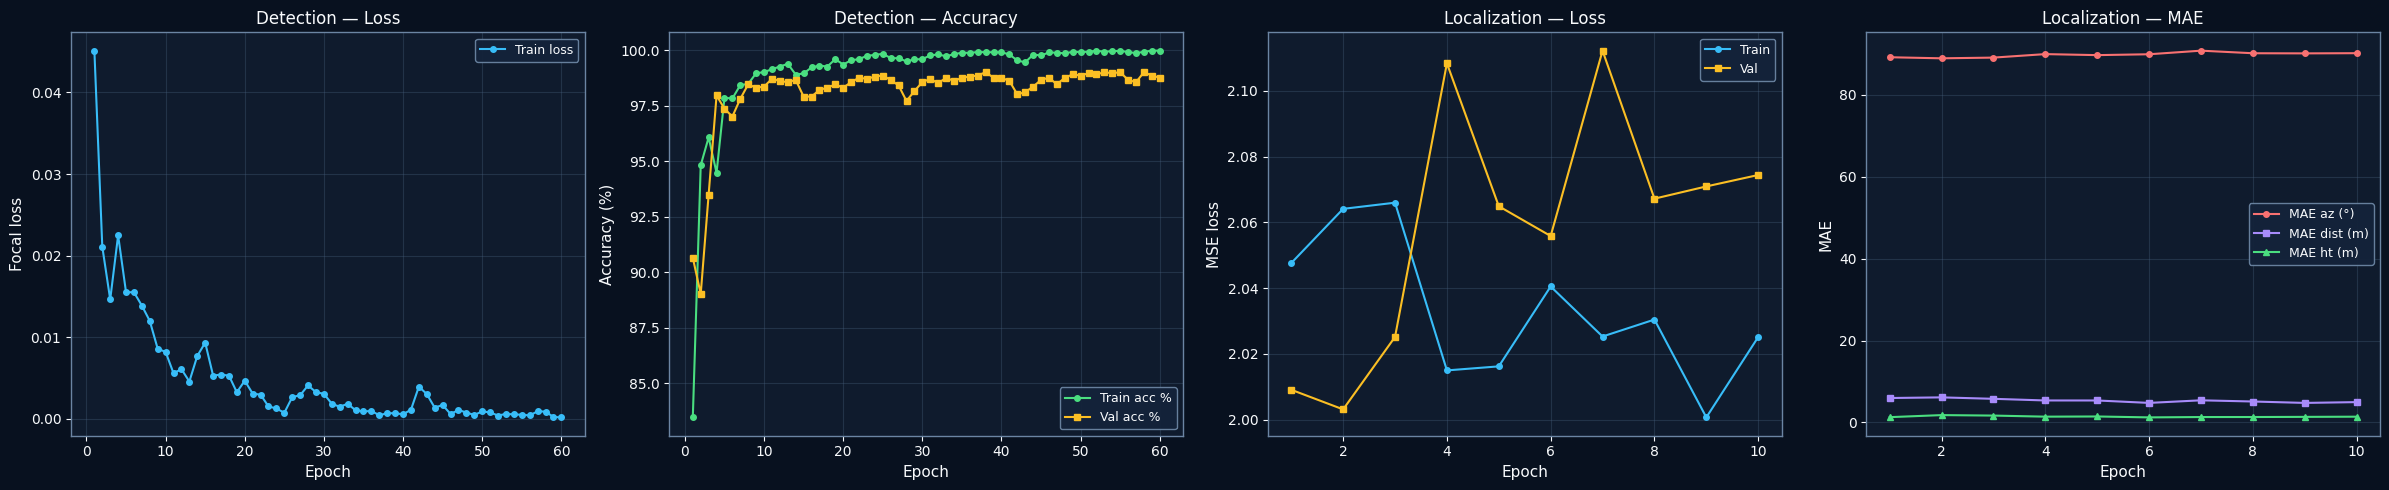

In [16]:
# Plotting training logs
from drone_detection.visualization import plot_training_logs
plot_training_logs(config)

In [ ]:
# It audits the processed labels already written into: config.PROCESSED_DIR / "localization"

audit_localization_labels(config)

  Sessions : 128
  Azimuth  : min=0.0°  max=315.0°  mean=157.5°  std=103.1°
  Distance : min=10.00m  max=20.00m  mean=15.00m
  Height   : min=10.00m  max=20.00m  mean=15.00m
  ⚠️  128/128 sessions have integer distance — possible placeholders


In [ ]:
# # Or train both together

# train_all(
#   cfg=config,
#   det_epochs=3,
#   loc_epochs=3,
#   use_synthetic_loc=True,
#   resume=False,
#   force_rebuild_cache=False,
#   custom_builder_root=root,
#   use_custom_builder=True,
#   import_custom_backgrounds_as_non_drone=True,
#   download_builtin_detection_dataset=True,
#   download_external_audio=True,
# )

In [ ]:
train_localization(
  config,
  reset_best=True,   # clears the old best checkpoint
  resume=False,      # start from scratch, not epoch 41
  epochs=10,
)

  STAGE 2 — Localization Model (UaVirBASE)
📥 Partial download: 2000 sessions via remotezip …
   Reading remote ZIP central directory …
   Candidate paired sessions: 132
   Validating labels …


Validating:   0%|          | 0/132 [00:00<?, ?it/s]

   Usable: 128 | Ambient skipped: 3 | Failed: 1

📐 Position-grouped split (32 unique positions):
   train:  80 sessions | 20 positions
   val  :  24 sessions |  6 positions
   test :  24 sessions |  6 positions
⚠️  Partial download failed (429 Client Error: TOO MANY REQUESTS for url: https://zenodo.org/records/15391924/files/Microphone_array.zip?download=1) → synthetic fallback.
🔬 Generating 2400 synthetic localization samples …


Synthetic loc:   0%|          | 0/2400 [00:00<?, ?it/s]

✅ Synthetic fallback: 2400 sessions written.
🔧 Using LocalizationCNN (full-capacity mode, ipd_in_dim=4)
   📊 Train: 1680 real + 500 synthetic = 2180 total
   📋 New log: /content/drive/MyDrive/drone_v15/logs/localization_log.csv


...

Loc ep 10:   0%|          | 0/68 [00:00<?, ?it/s]

Loc eval:   0%|          | 0/12 [00:00<?, ?it/s]

  Loc Ep  10 | tr=2.02516  val=2.07444  az=90.19°  dist=4.946m  ht=1.387m  lr=2.58e-05

🎯 Final localization test:


Loc eval:   0%|          | 0/12 [00:00<?, ?it/s]

  Val loss=2.04173  MAE az=89.77°  dist=4.976m  ht=1.383m


In [ ]:
train_localization(
  config,
  reset_best=True,   # clears the old best checkpoint
  resume=False,      # start from scratch, not epoch 41
  epochs=10,
)

In [26]:
# Generate, then inspect before evaluating
generate_single_drone_dataset(config, "/content/drive/MyDrive/AUS LAB II/test_dataset/test_single.zip", n_sessions=50)
plot_test_zip_overview("/content/drive/MyDrive/AUS LAB II/test_dataset/test_single.zip", config, n_sample_sessions=2,
                       save_path="/content/drive/MyDrive/AUS LAB II/test_dataset/plots/inspect_single")
# Saves inspect_single_labels.png, inspect_single_sessions.png, inspect_single_spatial.png

# # Multi-drone ZIP
# generate_multi_drone_dataset(config, "/content/drive/MyDrive/AUS LAB II/test_dataset/test_multi.zip", n_sessions=30)
# plot_test_zip_overview(
#   "/content/drive/MyDrive/AUS LAB II/test_dataset/test_multi.zip",
#   config, n_sample_sessions=2,
#   save_path="/content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_multi"
# )

# # Full scenario suite
# generate_scenario_dataset(config, "/content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios.zip")
# plot_test_zip_overview(
#   "/content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios.zip",
#   config, n_sample_sessions=2,
#   save_path="/content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_scenarios"
# )

✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
🔬 Single-drone dataset: 50 sessions  (array=uavirbase, noise=mixed)


  0%|          | 0/50 [00:00<?, ?it/s]

  Wrote: /content/drive/MyDrive/AUS LAB II/test_dataset/test_single.zip  (18.5 MB, 50 sessions)
📦 test_single.zip: 50 sessions, 50 labelled
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/inspect_single_labels.png
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/inspect_single_sessions.png
✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/inspect_single_spatial.png


In [27]:
# Multi-drone ZIP
generate_multi_drone_dataset(config, "/content/drive/MyDrive/AUS LAB II/test_dataset/test_multi.zip", n_sessions=30)
plot_test_zip_overview(
  "/content/drive/MyDrive/AUS LAB II/test_dataset/test_multi.zip",
  config, n_sample_sessions=2,
  save_path="/content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_multi"
)

✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
🔬 Multi-drone dataset: 30 sessions  (2-3 drones, array=uavirbase)


  0%|          | 0/30 [00:00<?, ?it/s]

  Wrote: /content/drive/MyDrive/AUS LAB II/test_dataset/test_multi.zip  (10.5 MB, 30 sessions)
📦 test_multi.zip: 30 sessions, 30 labelled
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_multi_labels.png
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_multi_sessions.png
✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_multi_spatial.png


In [28]:
# Full scenario suite
generate_scenario_dataset(config, "/content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios.zip")
plot_test_zip_overview(
  "/content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios.zip",
  config, n_sample_sessions=2,
  save_path="/content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_scenarios"
)

🔬 Scenario dataset: 9 scenarios, 165 sessions
✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
  indoor_hover         — Indoor studio, low altitude 1-4 m


  indoor_hover:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
  indoor_moving        — Indoor, larger distances and more noise


  indoor_moving:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
  outdoor_fly          — Outdoor flight, moderate wind


...

✅ Array geometry set to 'gp1'  baseline ≈ 2.421 m
  gp1_array            — PannoniaFS GP1 array, 2165 mm baseline


  gp1_array:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Array geometry set to 'gp2'  baseline ≈ 2.795 m
  gp2_array            — PannoniaFS GP2 array, 2500 mm baseline


  gp2_array:   0%|          | 0/20 [00:00<?, ?it/s]

  Wrote: /content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios.zip  (61.1 MB, 165 sessions)
📦 test_scenarios.zip: 165 sessions, 165 labelled
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_scenarios_labels.png
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_scenarios_sessions.png
✅ Array geometry set to 'uavirbase'  baseline ≈ 0.200 m
💾 Saved: /content/drive/MyDrive/AUS LAB II/test_dataset/plots/test_scenarios_spatial.png


In [29]:
from drone_detection.inference_test_loader import load_test_dataset_zip, run_test_dataset_evaluation

test_ds = load_test_dataset_zip(
  "/content/drive/MyDrive/AUS LAB II/test_dataset/test_single.zip",
  cfg=config,
  dataset_format="flat_wavs",   # or "uavirbase" / "pannoniafs" / "generic_triplet" / "flat_wavs" - # bypass auto-detect
  max_sessions=10,         # optional — useful for a quick smoke test
)
print(test_ds)  # shows session count and format

results = run_test_dataset_evaluation(test_ds, config, save_csv="/content/drive/MyDrive/AUS LAB II/test_dataset/test_single_dataset_results.csv")

📂 Extracting to temp dir: /tmp/drone_test_4d_1qymx
📦 Loading test dataset from test_single.zip …
✅ Extracted to /tmp/drone_test_4d_1qymx
   Indexing sessions (format='flat_wavs') …
   📋 Loaded 50 labels from labels.csv
✅ Indexed 10 sessions  (0 labelled, 10 unlabelled)
TestDataset(n=10, labelled=0, format='flat_wavs', zip='test_single.zip')

  Test dataset evaluation: test_single.zip
  Format: flat_wavs  |  Sessions: 10
Session                       Det  Prob   Az_p     Az_t     Err     Di_p    Di_t    Ht_p 
-----------------------------------------------------------------------------------------
session_0000                  YES  1.000     50.2        -       -    8.03       -   4.38
session_0001                  no   0.622      nan        -       -     nan       -    nan
session_0002                  no   0.301      nan        -       -     nan       -    nan
session_0003                  YES  1.000     46.8        -       -    9.85       -   4.74
session_0004                  YES  0

📂 Extracting to temp dir: /tmp/drone_test_mko95811
📦 Loading test dataset from test_scenarios.zip …
✅ Extracted to /tmp/drone_test_mko95811
   ZIP contents (661 files, first 20):
     indoor_moving_0002_ch2.wav
     indoor_moving_0010_ch2.wav
     gp2_array_0015_ch2.wav
     multi_drone_2_0019_label.json
     outdoor_fly_0006_ch2.wav
     outdoor_far_0011_ch0.wav
     gp1_array_0004_ch0.wav
     gp1_array_0017_label.json
     multi_drone_2_0007_ch0.wav
     multi_drone_3_0001_label.json
     low_snr_0007_ch2.wav
     indoor_moving_0002_label.json
     low_snr_0001_ch1.wav
     outdoor_fly_0015_ch1.wav
     low_snr_0003_ch2.wav
     low_snr_0003_ch1.wav
     indoor_hover_0019_label.json
     gp1_array_0019_label.json
     indoor_hover_0012_ch0.wav
     indoor_moving_0007_ch1.wav
     … and 641 more
   Detected format: 'generic_triplet'
   Indexing sessions (format='generic_triplet') …
✅ Indexed 10 sessions  (10 labelled, 0 unlabelled)
TestDataset(n=10, labelled=10, format='generic_tripl

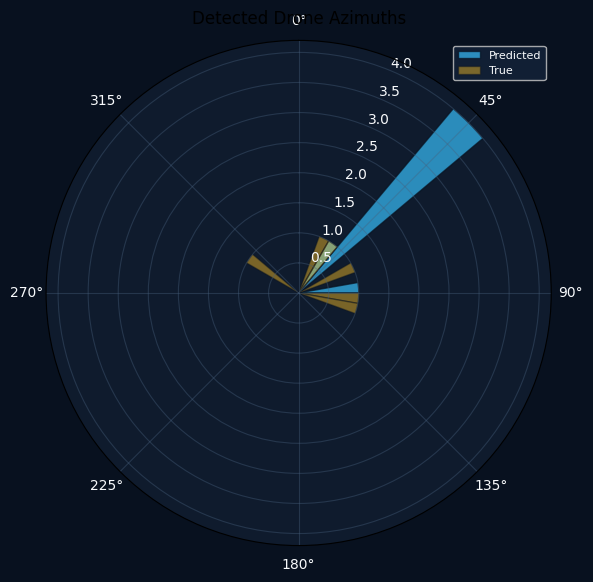

In [32]:
from drone_detection.inference_test_loader import load_test_dataset_zip, run_test_dataset_evaluation

test_ds = load_test_dataset_zip(
  "/content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios.zip",
  cfg=config,
  dataset_format="auto",   # or "uavirbase" / "pannoniafs" / "generic_triplet" / "flat_wavs" - # bypass auto-detect
  max_sessions=10,         # optional — useful for a quick smoke test
)
print(test_ds)  # shows session count and format

results = run_test_dataset_evaluation(test_ds, config, save_csv="/content/drive/MyDrive/AUS LAB II/test_dataset/test_scenarios_dataset_results.csv")

In [15]:
# Quick synthetic demo after training

demo_result = quick_demo(config)
demo_result


🚁 QUICK DEMO — Multi-drone synthetic test
──────────────────────────────────────────────────
  Detected: False  (conf=0.193)
  Drones found: 0
  Confirmed tracks: 0


{'detected': False,
 'probability': 0.19332570958778755,
 'cnn_probability': 9.45995343691608e-13,
 'heuristic_probability': 0.9666285479351537,
 'drones': [],
 'tracks': []}

In [25]:
# Test uploaded 3-mic files with one function

result = comprehensive_pipeline_test()

# # Or
# files = [
#   "/content/file1.wav",
#   "/content/file2.wav",
#   "/content/file3.wav",
# ]

# result = comprehensive_pipeline_test(files)

📁 Please upload exactly 3 audio files for Mic1, Mic2, and Mic3.


Saving yt_tmp_drone_00003_r001_p05.wav to yt_tmp_drone_00003_r001_p05 (1).wav
Saving yt_tmp_drone_00003_r001_p04.wav to yt_tmp_drone_00003_r001_p04.wav
Saving yt_tmp_drone_00003_r001_p03.wav to yt_tmp_drone_00003_r001_p03 (1).wav
✅ Uploaded files:
   Mic 1: yt_tmp_drone_00003_r001_p03 (1).wav
   Mic 2: yt_tmp_drone_00003_r001_p04.wav
   Mic 3: yt_tmp_drone_00003_r001_p05 (1).wav
🔄 Loading models...

🔊 Loading 3-channel audio...

🚁 Running single-drone pipeline...

🚁🚁 Running multi-drone pipeline...

COMPREHENSIVE PIPELINE TEST SUMMARY

🎵 Input files
  Mic 1: yt_tmp_drone_00003_r001_p03 (1).wav
  Mic 2: yt_tmp_drone_00003_r001_p04.wav
  Mic 3: yt_tmp_drone_00003_r001_p05 (1).wav

🔊 Channel statistics
  Ch1: shape=(66150,)  dtype=float32  min=-0.64230  max=0.62329  rms=-14.54 dB
  Ch2: shape=(66150,)  dtype=float32  min=-0.75201  max=0.74744  rms=-16.67 dB
  Ch3: shape=(66150,)  dtype=float32  min=-0.72202  max=0.67548  rms=-15.78 dB

🚁 Single-drone pipeline
  detected               : Tr

In [ ]:
# Launch the Colab UI

launch_ui(config)

Saving DJI_drones_noise_comparson_seg_038_0145941_0149941_0001000_0004000_seg_001_0000000_0003120.wav to DJI_drones_noise_comparson_seg_038_0145941_0149941_0001000_0004000_seg_001_0000000_0003120.wav


Saving siren_fold8_148632_9.wav to siren_fold8_148632_9.wav
Saving siren_fold8_117181_0.wav to siren_fold8_117181_0.wav
Saving siren_fold7_107357_8.wav to siren_fold7_107357_8.wav


In [ ]:
# Test uploaded 3-mic files with one function

result = comprehensive_pipeline_test()

# # Or
# files = [
#   "/content/file1.wav",
#   "/content/file2.wav",
#   "/content/file3.wav",
# ]

# result = comprehensive_pipeline_test(files)

📁 Please upload exactly 3 audio files for Mic1, Mic2, and Mic3.


Saving klemenflerin-drone-fly-397287_0010000_0247920.wav to klemenflerin-drone-fly-397287_0010000_0247920.wav
Saving Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_015_0051798_0055798_0001000_0004000.wav to Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_015_0051798_0055798_0001000_0004000.wav
Saving Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_012_0040548_0044548_0001000_0004000.wav to Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_012_0040548_0044548_0001000_0004000.wav
✅ Uploaded files:
   Mic 1: Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_012_0040548_0044548_0001000_0004000.wav
   Mic 2: Drone_Noise_Test_-_DJI_Avata_vs_DJI_FPV_vs_DJI_Mavic_3_vs_DJI_Air_2S_compared_seg_015_0051798_0055798_0001000_0004000.wav
   Mic 3: klemenflerin-drone-fly-397287_0010000_0247920.wav
🔄 Loading models...

🔊 Loading 3-channel


🚁 QUICK DEMO — Multi-drone synthetic test
──────────────────────────────────────────────────
  Detected: True  (conf=1.000)
  Drones found: 3
    Drone 1: (-13.37,21.12)m  az=122.6°  dist=25.00m  err=25.503m
    Drone 2: (20.84,14.02)m  az=34.0°  dist=25.00m  err=25.024m
    Drone 3: (0.37,-0.10)m  az=-30.0°  dist=0.31m
💾 Saved: /content/drive/MyDrive/drone_v15/logs/plots/multi_drone_positions.png


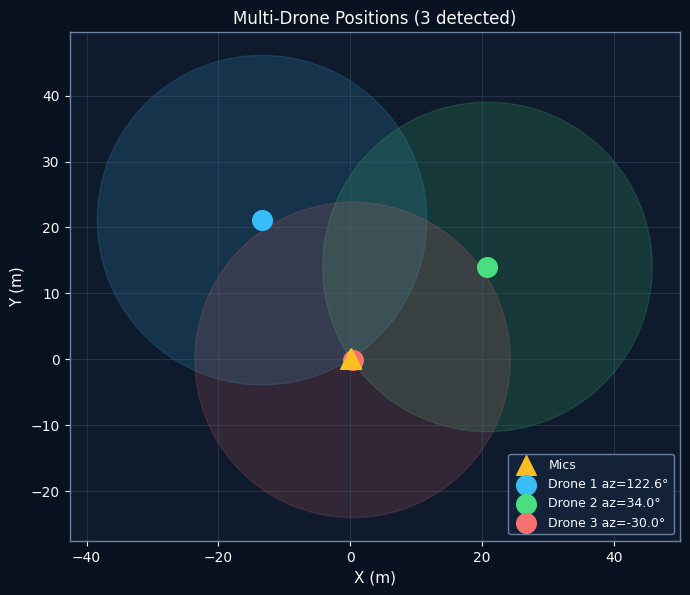

  Confirmed tracks: 3
    Track #3: pos=(-13.37,21.12)m  hits=1  dist=0.000m
    Track #4: pos=(20.84,14.02)m  hits=1  dist=0.000m
    Track #5: pos=(0.37,-0.10)m  hits=1  dist=0.000m
💾 Saved: /content/drive/MyDrive/drone_v15/logs/plots/track_trajectory.png


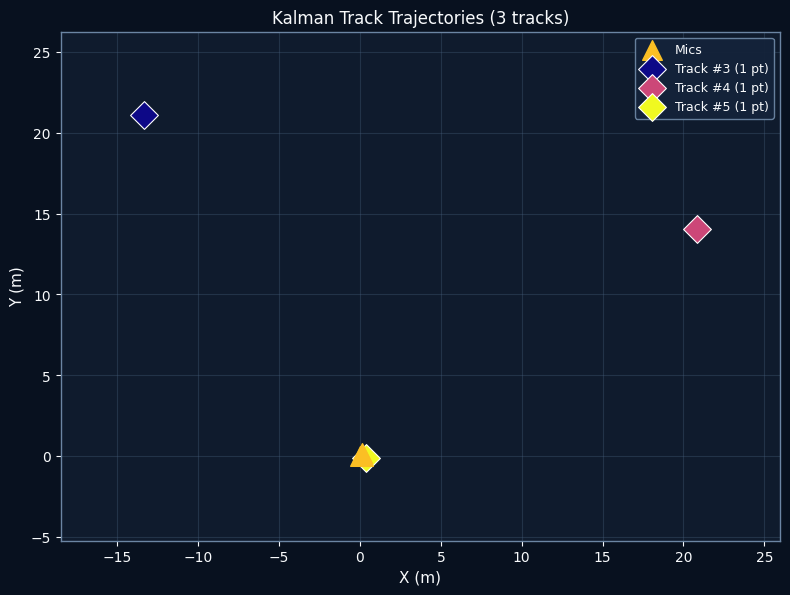

{'detected': True,
 'probability': 1.0,
 'cnn_probability': 1.0,
 'heuristic_probability': 0.9728569212590056,
 'drones': [{'xy_position': array([-13.371236,  21.117786], dtype=float32),
   'azimuth_deg': 122.60534921118966,
   'distance_m': 25.0,
   'tdoa_residual': 7.700231305488377e-11,
   'confidence_radius': 25.0},
  {'xy_position': array([20.83701 , 14.021234], dtype=float32),
   'azimuth_deg': 33.95480029366549,
   'distance_m': 25.000057220458984,
   'tdoa_residual': 8.15564552719485e-09,
   'confidence_radius': 25.0},
  {'xy_position': array([ 0.36578903, -0.09572623], dtype=float32),
   'azimuth_deg': -30.00100152533768,
   'distance_m': 0.30690982937812805,
   'tdoa_residual': 1.2903105862002936e-22,
   'confidence_radius': 23.925767963401906}],
 'tracks': [<drone_detection.tracking.KalmanTrack at 0x7bcbfd653140>,
  <drone_detection.tracking.KalmanTrack at 0x7bcbfd573410>]}

In [ ]:
quick_demo(config)

In [ ]:
# Launch the Colab UI

launch_ui(config)

Saving siren_fold1_106905_1.wav to siren_fold1_106905_1.wav


Saving klemenflerin-drone-fly-397287_0010000_0247920_seg_054_0198750_0202750.wav to klemenflerin-drone-fly-397287_0010000_0247920_seg_054_0198750_0202750.wav



🎧 Robust External Audio Analysis
🎵 File: DJI drones noise comparson.mp3 | duration=179.37s | 358 segments
  Seg   1 🌳 prob=0.000  cnn=0.000  heur=0.000  [0.00–1.00s]
  Seg   2 🌳 prob=0.000  cnn=0.000  heur=0.000  [0.50–1.50s]
  Seg   3 🌳 prob=0.000  cnn=0.000  heur=0.000  [1.00–2.00s]
  Seg   4 🌳 prob=0.000  cnn=0.000  heur=0.000  [1.50–2.50s]
  Seg   5 🌳 prob=0.000  cnn=0.000  heur=0.000  [2.00–3.00s]
  Seg   6 🌳 prob=0.000  cnn=0.000  heur=0.000  [2.50–3.50s]
  Seg   7 🌳 prob=0.000  cnn=0.000  heur=0.000  [3.00–4.00s]
  Seg   8 🌳 prob=0.000  cnn=0.000  heur=0.000  [3.50–4.50s]
  Seg   9 🌳 prob=0.000  cnn=0.000  heur=0.000  [4.00–5.00s]
  Seg  10 🌳 prob=0.000  cnn=0.000  heur=0.000  [4.50–5.50s]
  Seg  11 🚁 prob=0.971  cnn=1.000  heur=0.556  [5.00–6.00s]
  Seg  12 🚁 prob=0.885  cnn=1.000  heur=0.423  [5.50–6.50s]
  Seg  13 🌳 prob=0.000  cnn=0.000  heur=0.000  [6.00–7.00s]
  Seg  14 🌳 prob=0.000  cnn=0.000  heur=0.000  [6.50–7.50s]
  Seg  15 🚁 prob=0.881  cnn=1.000  heur=0.405  [7.00–

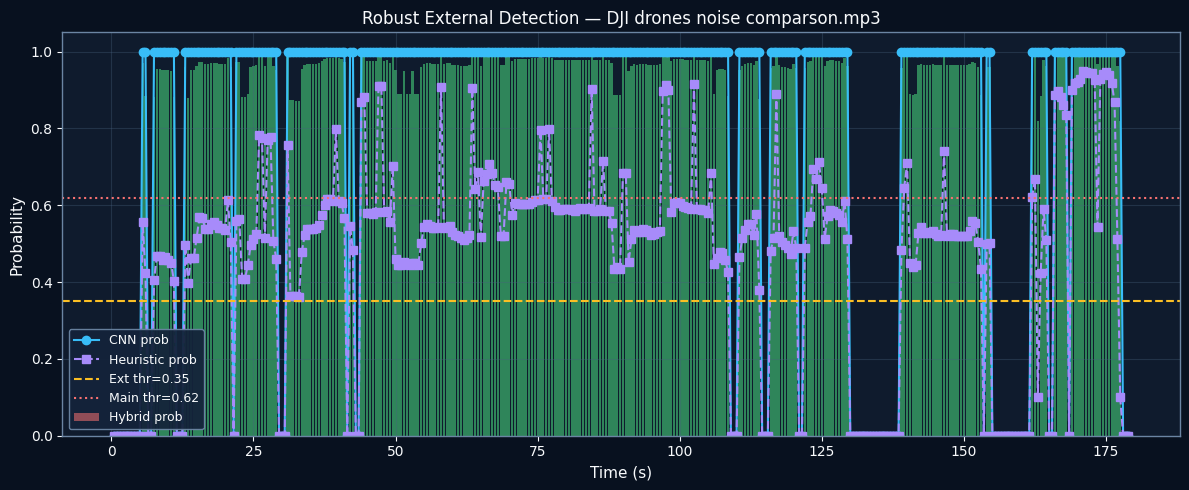

{'file': '/content/DJI drones noise comparson.mp3',
 'duration_s': 179.37414965986395,
 'segment_results': [{'segment_index': 1,
   't_start_s': 0.0,
   't_end_s': 1.0,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic_probability': 0.0,
   'label': 'non_drone',
   'detected_at_main_threshold': False,
   'detected_at_external_threshold': False},
  {'segment_index': 2,
   't_start_s': 0.5,
   't_end_s': 1.5,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic_probability': 0.0,
   'label': 'non_drone',
   'detected_at_main_threshold': False,
   'detected_at_external_threshold': False},
  {'segment_index': 3,
   't_start_s': 1.0,
   't_end_s': 2.0,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic_probability': 0.0,
   'label': 'non_drone',
   'detected_at_main_threshold': False,
   'detected_at_external_threshold': False},
  {'segment_index': 4,
   't_start_s': 1.5,
   't_end_s': 2.5,
   'probability': 0.0,
   'cnn_probability': 0.0,
   'heuristic

In [ ]:
# Analyse External audio file
from drone_detection.inference import analyse_external_audio_robust

audio_path='/content/DJI drones noise comparson.mp3'
analyse_external_audio_robust(cfg=config, audio_path=audio_path)

In [23]:
import torch
import numpy as np
import drone_detection.inference as _inf

def _detect_fixed(channels, cfg=None, use_hybrid=True):
    import math
    from drone_detection.config import config as _config
    from drone_detection.audio_processing import AudioProcessor
    from drone_detection.utils import classify_detection_score, sigmoid

    cfg = cfg or _config
    ap  = AudioProcessor(cfg)
    y0  = ap.pad_or_truncate(np.asarray(channels[0], dtype=np.float32))
    rms_db = float(20 * math.log10(float(np.sqrt(np.mean(y0 ** 2))) + 1e-8))

    if rms_db < _inf._RMS_FLOOR_DB:
        return {"detected": False, "probability": 0.0, "label": "non_drone",
                "cnn_probability": 0.0, "heuristic_probability": 0.0,
                "heuristic_features": {"veto": "below_rms_floor", "rms_db": rms_db}}

    m    = _inf.load_detection_model(cfg)

    # ✅ FIX: use feature_stack to match training preprocessing
    feat = ap.feature_stack(y0)
    x    = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(cfg.DEVICE)

    with torch.no_grad():
        cnn_prob = float(torch.softmax(m(x), dim=1)[0, 1].item())

    heur           = _inf.heuristic_detect(y0, cfg)
    heuristic_prob = float(heur["probability"])

    if use_hybrid:
        fused_prob = 0.80 * cnn_prob + 0.20 * heuristic_prob
        if cnn_prob > 0.45 and heuristic_prob > 0.45:
            fused_prob = min(1.0, fused_prob + 0.06)
        if cnn_prob < 0.55 and heur["features"].get("veto"):
            fused_prob = min(fused_prob, 0.40)
    else:
        fused_prob = cnn_prob

    label = classify_detection_score(fused_prob, cfg)
    return {"detected": bool(fused_prob >= cfg.DETECTION_THRESHOLD),
            "probability": float(fused_prob), "label": label,
            "cnn_probability": float(cnn_prob),
            "heuristic_probability": float(heuristic_prob),
            "heuristic_features": heur["features"]}

# Monkey-patch the module
_inf.detect = _detect_fixed
print("✅ detect() patched — feature_stack now used for CNN input")

✅ detect() patched — feature_stack now used for CNN input


In [24]:
from drone_detection import synthesise_drone
from drone_detection.audio_processing import AudioProcessor

ap  = AudioProcessor(config)
chs = synthesise_drone(config.MIC_POSITIONS, [1.5, 0.5], fundamental=100, noise_level=0.02)

result = _inf.detect(chs, config)
print(f"CNN prob     : {result['cnn_probability']:.4f}")
print(f"Heuristic    : {result['heuristic_probability']:.4f}")
print(f"Fused prob   : {result['probability']:.4f}")
print(f"Detected     : {result['detected']}")

CNN prob     : 0.9861
Heuristic    : 0.9477
Fused prob   : 1.0000
Detected     : True


In [22]:
from pathlib import Path
ckpt = config.DRIVE_MODELS / "best_detection.pth"
print(f"Exists: {ckpt.exists()}")
print(f"Path:   {ckpt}")
import torch
ck = torch.load(ckpt, map_location="cpu")
print(f"Epoch:     {ck.get('epoch')}")
print(f"Val F1:    {ck.get('best_val_f1')}")
print(f"Threshold: {ck.get('best_threshold')}")
import torch
from drone_detection import DetectionCNN
import numpy as np

m = DetectionCNN()
ck = torch.load(config.DRIVE_MODELS / "best_detection.pth", map_location="cpu")
m.load_state_dict(ck["model_state"])
m.eval()

# Try with a synthetic drone signal to see if CNN responds at all
from drone_detection import synthesise_drone, AudioProcessor
ap = AudioProcessor(config)
chs = synthesise_drone(config.MIC_POSITIONS, [1.5, 0.5], fundamental=100, noise_level=0.02)
mel = ap.mel(ap.pad_or_truncate(chs[0]))
x = torch.tensor(np.stack([mel]*3), dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    probs = torch.softmax(m(x), dim=1)
print(f"non_drone: {probs[0,0]:.4f}  drone: {probs[0,1]:.4f}")

Exists: True
Path:   /content/drive/MyDrive/drone_v15/models/best_detection.pth
Epoch:     58
Val F1:    0.9754901960784313
Threshold: 0.7549999999999999
non_drone: 1.0000  drone: 0.0000


In [31]:
from drone_detection import visualization as _viz
import numpy as np

def _polar_azimuth_fixed(azimuth_degs, title="Detected Drone Azimuths",
                          cfg=None, save=True, true_azimuths=None):
    from drone_detection.config import config as _config
    import matplotlib.pyplot as plt
    cfg = cfg or _config
    fig = plt.figure(figsize=(6, 6), facecolor=_viz.PLOT_STYLE["bg"])
    ax  = fig.add_subplot(111, projection="polar")
    ax.set_facecolor(_viz.PLOT_STYLE["panel"])
    ax.tick_params(colors=_viz.PLOT_STYLE["text"])
    rads = np.radians([90 - a for a in azimuth_degs])
    counts, edges = np.histogram(rads, bins=36, range=(-np.pi, np.pi))
    centers = 0.5 * (edges[:-1] + edges[1:])
    ax.bar(centers, counts, width=edges[1]-edges[0], alpha=0.7,
           color=_viz.PLOT_STYLE["accent"], edgecolor=_viz.PLOT_STYLE["bg"], label="Predicted")
    if true_azimuths:
        tr = np.radians([90 - a for a in true_azimuths])
        tc, _ = np.histogram(tr, bins=36, range=(-np.pi, np.pi))
        ax.bar(centers, tc, width=edges[1]-edges[0], alpha=0.45,
               color=_viz.PLOT_STYLE["warn"], edgecolor=_viz.PLOT_STYLE["bg"], label="True")
        ax.legend(loc="upper right", facecolor=_viz.PLOT_STYLE["panel_alt"],
                  labelcolor=_viz.PLOT_STYLE["text"], fontsize=8)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    ax.set_title(title, pad=12); ax.grid(color=_viz.PLOT_STYLE["grid"], alpha=0.4)
    plt.tight_layout()
    if save:
        _viz._save_plot(fig, cfg.DRIVE_PLOTS / "polar_azimuth.png")
    _viz._show_inline(fig); plt.close(fig)

_viz.plot_polar_azimuth = _polar_azimuth_fixed
print("✅ plot_polar_azimuth patched")

✅ plot_polar_azimuth patched
